# NB14 — Cross-Validation and Model Selection

> **StatQuest: "Never use the same data to both train and evaluate your model."**

---

## The main ideas:

1. Train R^2 always improves with complexity — useless for model selection
2. Train/test split: better, but wastes data and has high variance
3. **k-fold cross-validation:** split data into k folds, train on k-1, test on 1, rotate — use all data for both
4. **Learning curves:** diagnose whether you have a bias or variance problem
5. **Nested CV:** unbiased performance estimate when ALSO tuning hyperparameters


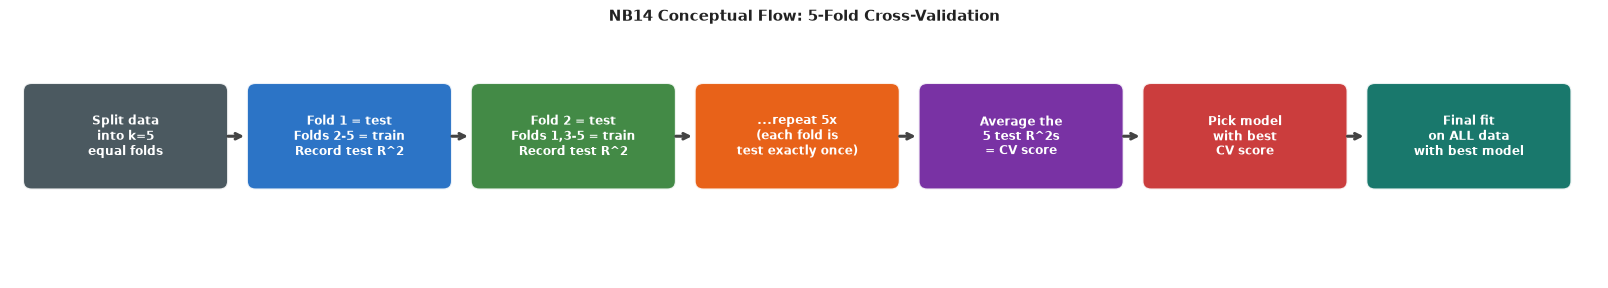

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Split data\ninto k=5\nequal folds',
        'Fold 1 = test\nFolds 2-5 = train\nRecord test R^2',
        'Fold 2 = test\nFolds 1,3-5 = train\nRecord test R^2',
        '...repeat 5x\n(each fold is\ntest exactly once)',
        'Average the\n5 test R^2s\n= CV score',
        'Pick model\nwith best\nCV score',
        'Final fit\non ALL data\nwith best model',
    ],
    title='NB14 Conceptual Flow: 5-Fold Cross-Validation',
    colors=['#37474F','#1565C0','#2E7D32','#E65100','#6A1B9A','#C62828','#00695C'],
    figsize=(16, 2.8),
)


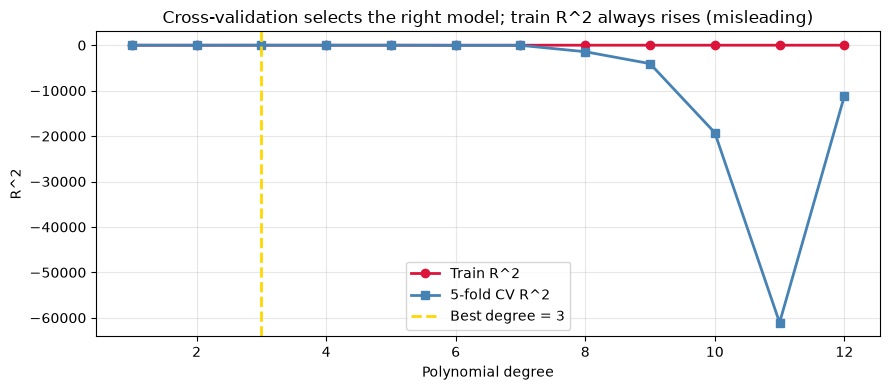

Best degree by CV: 3
Train R^2 at degree 3: 0.8111
CV    R^2 at degree 3: 0.2813


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(42)
n = 100
X = np.sort(np.random.uniform(-3, 3, n)).reshape(-1,1)
y = np.sin(X.ravel()) + np.random.normal(0, 0.4, n)

degrees = range(1, 13)
train_r2, cv_r2 = [], []

for deg in degrees:
    pipe = Pipeline([('poly', PolynomialFeatures(deg)), ('ols', LinearRegression())])
    # Train R^2
    pipe.fit(X, y)
    train_r2.append(pipe.score(X, y))
    # 5-fold CV R^2
    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    cv_r2.append(scores.mean())

best_deg = degrees[np.argmax(cv_r2)]
plt.figure(figsize=(9, 4))
plt.plot(degrees, train_r2, 'o-', color='crimson', linewidth=2, label='Train R^2')
plt.plot(degrees, cv_r2,   's-', color='steelblue', linewidth=2, label='5-fold CV R^2')
plt.axvline(best_deg, color='gold', linewidth=2, linestyle='--',
            label=f'Best degree = {best_deg}')
plt.xlabel('Polynomial degree'); plt.ylabel('R^2')
plt.title('Cross-validation selects the right model; train R^2 always rises (misleading)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"Best degree by CV: {best_deg}")
print(f"Train R^2 at degree {best_deg}: {train_r2[best_deg-1]:.4f}")
print(f"CV    R^2 at degree {best_deg}: {cv_r2[best_deg-1]:.4f}")


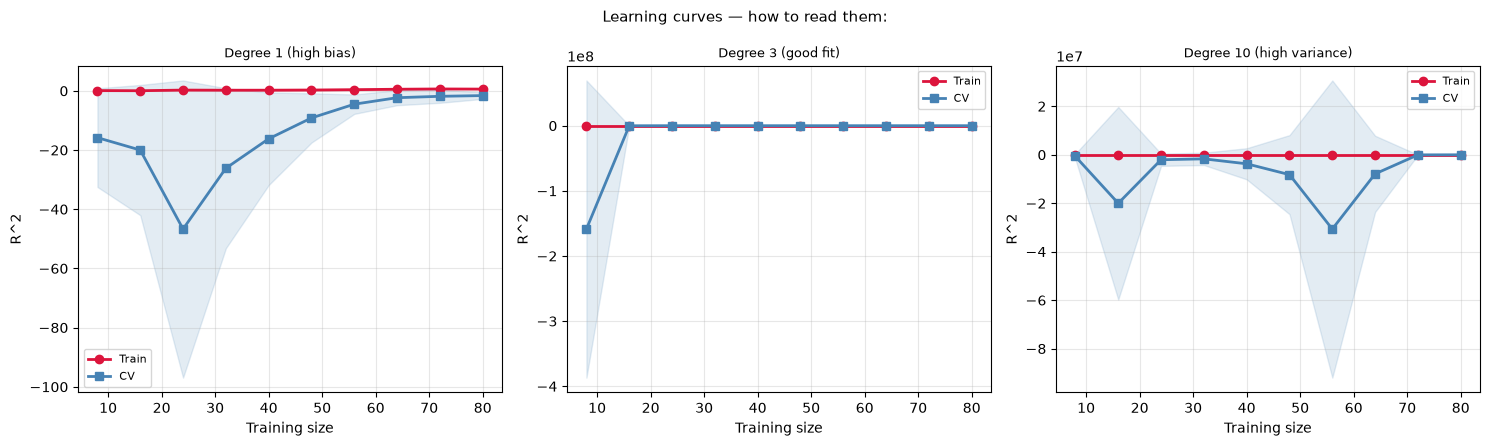

High bias: both curves low and converge (add features or complexity)
High variance: big gap between train and CV curves (add more data or regularise)


In [3]:
# Learning curves — diagnose bias vs variance
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

models = {
    'Degree 1 (high bias)':    Pipeline([('p', PolynomialFeatures(1)), ('m', LinearRegression())]),
    'Degree 3 (good fit)':     Pipeline([('p', PolynomialFeatures(3)), ('m', LinearRegression())]),
    'Degree 10 (high variance)':Pipeline([('p', PolynomialFeatures(10)),('m', LinearRegression())]),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, m) in zip(axes, models.items()):
    sizes, tr_sc, te_sc = learning_curve(
        m, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10))
    tr_mean = tr_sc.mean(axis=1); tr_std = tr_sc.std(axis=1)
    te_mean = te_sc.mean(axis=1); te_std = te_sc.std(axis=1)

    ax.fill_between(sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='crimson')
    ax.fill_between(sizes, te_mean-te_std, te_mean+te_std, alpha=0.15, color='steelblue')
    ax.plot(sizes, tr_mean, 'o-', color='crimson',   linewidth=2, label='Train')
    ax.plot(sizes, te_mean, 's-', color='steelblue', linewidth=2, label='CV')
    ax.set_title(name, fontsize=9); ax.set_xlabel('Training size')
    ax.set_ylabel('R^2'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Learning curves — how to read them:', fontsize=11)
plt.tight_layout(); plt.show()
print("High bias: both curves low and converge (add features or complexity)")
print("High variance: big gap between train and CV curves (add more data or regularise)")


## Key Takeaways

| Technique | Use for | Watch out for |
|-----------|---------|--------------|
| Train R^2 alone | Nothing | Always misleading for model selection |
| k-fold CV | Model selection, hyperparameter tuning | Still can overfit if you tune on CV score |
| Nested CV | Unbiased performance estimate | More expensive |
| Learning curve | Diagnosing bias vs variance | Need enough range of sizes |

**Next: NB15 — Gradient Descent: the iterative alternative to normal equations.**
